Given the root of a binary tree, return its depth.

The depth of a binary tree is defined as the number of nodes along the longest path from the root node down to the farthest leaf node.

Example 1:

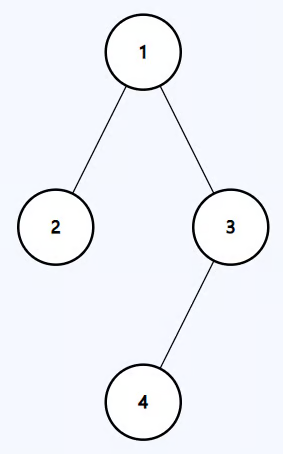

Input: root = [1,2,3,null,null,4]

Output: 3

Example 2:

Input: root = []

Output: 0

In [3]:
from typing import Optional

# Recursive DFS

Intuition

Recursive DFS computes the maximum depth of a binary tree by exploring every node.

The idea is simple:

The depth of a tree = 1 + maximum depth of its left and right subtrees.

If a node is None, its depth is 0.

So for each node:

Recursively compute the depth of the left subtree.

Recursively compute the depth of the right subtree.

Take the maximum of the two.

Add 1 for the current node.

Algorithm

If root is null, return 0.

Otherwise:

Recursively compute leftDepth = maxDepth(root.left).

Recursively compute rightDepth = maxDepth(root.right).

Return 1 + max(leftDepth, rightDepth).

In [ ]:
# Definition for a binary tree node.
class TreeNode:
    def __init__(self, val=0, left=None, right=None):
        self.val = val
        self.left = left
        self.right = right

# Time Complexity: O(n)
# Space Complexity: O(h)
# where n is the number of nodes in the tree and h is the height of the tree
class Solution:
    def maxDepth(self, root: Optional[TreeNode]) -> int:
        if not root:
            return 0
        left_depth = self.maxDepth(root.left)
        right_depth = self.maxDepth(root.right)
        return max(left_depth, right_depth) + 1

In [5]:
root = TreeNode(4)
root.left        = TreeNode(2)
root.right       = TreeNode(7)
root.left.left   = TreeNode(1)
root.left.right  = TreeNode(3)
root.right.left  = TreeNode(6)
root.right.right = TreeNode(9)

# --- max depth ---
solution = Solution()
max_depth = solution.maxDepth(root)

print(max_depth)  # 3

3


# Iterative DFS (Stack)

Intuition

To invert (mirror) a binary tree, every node must swap its left and right children. Using Breadth-First Search (BFS), we process the tree level-by-level:

Start from the root.

For each node, swap its children.

Then push the (new) left and right children into the queue.

Continue until every node has been processed.

This approach ensures that every node is visited exactly once and inverted immediately when encountered.

Algorithm

If the tree is empty, return null.

Initialize a queue and insert the root node.

While the queue is not empty:

Remove the front node.

Swap its left and right children.

If the left child exists, add it to the queue.

If the right child exists, add it to the queue.

After all nodes are processed, return the root as the inverted tree.


In [ ]:
# DFS
# Time Complexity: O(n)
# Space Complexity: O(n)
class Solution:
    def maxDepth(self, root: Optional[TreeNode]) -> int:
        stack = [[root, 1]]
        res = 0

        while stack:
            node, depth = stack.pop()

            if node:
                res = max(res, depth)
                stack.append([node.left, depth + 1])
                stack.append([node.right, depth + 1])
        return res

# BFS

Intuition

Breadth-First Search (BFS) processes the tree level by level.

This makes it a perfect fit for computing the maximum depth because:

Every iteration of BFS processes one entire level of the tree.

So each completed level corresponds to increasing the depth by 1.

We simply count how many levels we traverse until the queue becomes empty.

Think of the queue like a moving frontier:

Start with the root → depth = 1

Add its children → depth = 2

Add their children → depth = 3

Continue until no nodes remain.

The number of BFS layers processed is exactly the depth of the tree.

Algorithm

If the tree is empty (root == null), return 0.

Initialize a queue and push the root.

Initialize level = 0.

While the queue is not empty:

Determine the number of nodes at the current level (size = len(queue)).

Process all size nodes:

Pop from the queue.

Push their left and right children if they exist.

After processing the entire level, increment level.

Return level when the queue becomes empty.

In [ ]:
# BFS
# Time Complexity: O(n)
# Space Complexity: O(n)

from collections import deque

class Solution:
    def maxDepth(self, root: Optional[TreeNode]) -> int:
        q = deque()
        if root:
            q.append(root)

        level = 0
        while q:
            for i in range(len(q)):
                node = q.popleft()
                if node.left:
                    q.append(node.left)
                if node.right:
                    q.append(node.right)
            level += 1
        return level